In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use("seaborn-v0_8-paper")  # 干净的浅色主题（可换 "default"）

mpl.rcParams.update({
    # ---- 字体 ----
    "font.family": "sans-serif",               # 可改为 "sans-serif" 或 "Times New Roman"
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # ---- 轴线与边框 ----
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1,
    "axes.edgecolor": "black",
    
    # ---- 刻度与网格 ----
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.4,
    
    # ---- 图例 ----
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.handleheight": 0.8,
    
    # ---- 图形布局 ----
    "figure.dpi": 200,
    "figure.figsize": (6, 4),
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

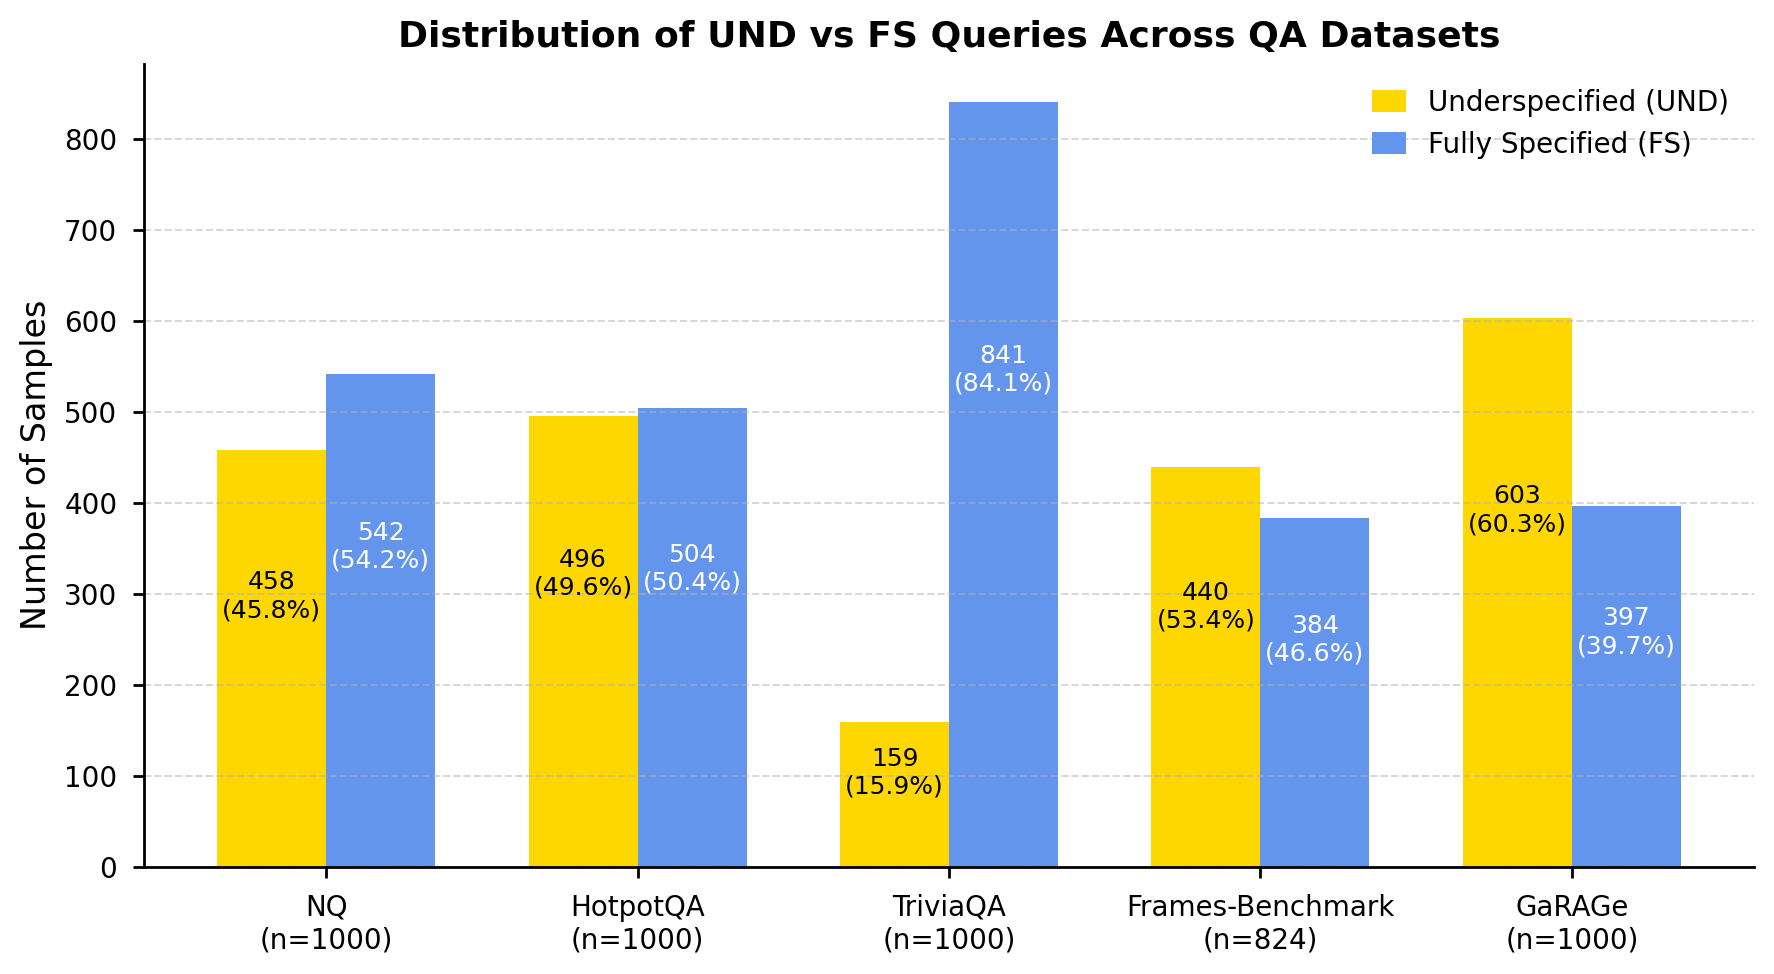

In [37]:
# 数据
data = {
    "Dataset": ["NQ", "HotpotQA", "TriviaQA", "Frames-Benchmark", "GaRAGe"],
    "UND": [458, 496, 159, 440, 603],
    "FS": [542, 504, 841, 384, 397],
    "Total": [1000, 1000, 1000, 824, 1000],
}

df = pd.DataFrame(data)

# 计算百分比
df["UND_ratio"] = df["UND"] / df["Total"] * 100
df["FS_ratio"] = df["FS"] / df["Total"] * 100

# 绘图
plt.figure(figsize=(9, 5))
bar_width = 0.35
x = range(len(df))

# 柱状图
bars1 = plt.bar([i - bar_width/2 for i in x], df["UND"], width=bar_width, label="Underspecified (UND)", color="#FFD700")
bars2 = plt.bar([i + bar_width/2 for i in x], df["FS"], width=bar_width, label="Fully Specified (FS)", color="#6495ED")

# 在 bar 内标注文字
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    plt.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() * 0.65,
             f"{df['UND'][i]}\n({df['UND_ratio'][i]:.1f}%)",
             ha='center', va='center', fontsize=9, color='black')
    plt.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() * 0.65,
             f"{df['FS'][i]}\n({df['FS_ratio'][i]:.1f}%)",
             ha='center', va='center', fontsize=9, color='white')

# ✅ 改进关键部分：x轴标签两行
xtick_labels = [f"{row['Dataset']}\n(n={row['Total']})" for _, row in df.iterrows()]
plt.xticks(x, xtick_labels, rotation=0, ha="center", fontsize=10)

plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of UND vs FS Queries Across QA Datasets", fontsize=13, weight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## A function for combined figures of UND vs. FS

In [3]:
def produce_em_f1_AA_plots(und_file, fs_file, model_name, dataset_name, em_p, f1_p, AA_p, em_y_top):
    # ========= 参数与样式 =========
    und_path = f"./output_csv/{und_file}.csv"
    fs_path  = f"./output_csv/{fs_file}.csv"

    COLORS = ["#FFD700", "#6495ED"]  # UND / FS
    LABELS = ["UND", "FS"]

    # ========= 工具函数 =========
    def to_percent_if_needed(a: np.ndarray) -> np.ndarray:
        """若数值最大不超过 1，则乘以 100 变为百分比。"""
        a = a.astype(float)
        if np.nanmax(a) <= 1.0:
            a = a * 100.0
        return a

    def sem(a: np.ndarray) -> float:
        a = a.astype(float)
        return float(np.nanstd(a, ddof=1) / np.sqrt(np.sum(~np.isnan(a))))

    def add_pvalue_bracket(ax, text, x1=1.0, x2=2.0,
                       y_top=100.0, inset=5.0, height=2.0,
                       text_x=None, text_dy=0.6, lw=1.2):
        """
        在 y_top 下方画“∪”形括号，p 值文字在括号下方（适合 0-100% 纵轴）。
        x1/x2 是两组的横坐标（与 set_xticks 对齐），y_top 是图顶参考值（可略高于 ylim 上限），
        inset 控制括号整体下移，height 控制括号高度。
        """
        y_base = y_top - inset
        y_top_line = y_base + height
        if text_x is None:
            text_x = (x1 + x2) / 2.0
        ax.plot([x1, x1, x2, x2],
                [y_base, y_top_line, y_top_line, y_base],
                lw=lw, c="black", clip_on=False)
        ax.text(text_x, y_base - text_dy, text,
                ha="center", va="top", fontsize=11, clip_on=False)

    # ========= 读数 =========
    UND = pd.read_csv(und_path)
    FS  = pd.read_csv(fs_path)

    # ========= 准备三组数据 =========
    # 1) EM（已知是 0–1 或 0–100，统一转为百分比）
    und_em = to_percent_if_needed(UND["em"].dropna().values)
    fs_em  = to_percent_if_needed(FS["em"].dropna().values)

    em_means = [float(np.nanmean(und_em)), float(np.nanmean(fs_em))]
    em_sems  = [sem(und_em), sem(fs_em)]
    em_ns    = [len(und_em), len(fs_em)]

    # 2) F1
    und_f1 = to_percent_if_needed(UND["f1"].dropna().values)
    fs_f1  = to_percent_if_needed(FS["f1"].dropna().values)
    f1_ns  = [len(und_f1), len(fs_f1)]

    # 3) RAGAS AA short
    und_aa = to_percent_if_needed(UND["ragas_AA_short"].dropna().values)
    fs_aa  = to_percent_if_needed(FS["ragas_AA_short"].dropna().values)
    aa_ns  = [len(und_aa), len(fs_aa)]

    # ========= 画三联图 =========
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    ax0, ax1, ax2 = axes

    # ---- 左：EM 柱状图 ----
    bars = ax0.bar([1, 2], em_means, yerr=em_sems,
                color=COLORS, edgecolor="black", capsize=5, width=0.6)
    ax0.set_xticks([1, 2])
    ax0.set_xticklabels(LABELS, fontsize=11)
    ax0.set_ylabel("Accuracy / Score (%)", fontsize=12)  # 与其他两图共享同一纵轴含义
    ax0.set_title("Exact Match (EM)", fontsize=13, weight="bold", pad=30)
    ax0.grid(axis="y", linestyle="--", alpha=0.5)

    # 在柱内标注均值和样本数
    for i, (bar, mean, n) in enumerate(zip(bars, em_means, em_ns)):
        height = bar.get_height()
        # 文字颜色按背景对比来简单区分（可按需微调）
        text_color = "black" if i == 0 else "white"
        ax0.text(bar.get_x() + bar.get_width()/2,
                height * 0.5,
                f"{mean:.1f}%",
                ha="center", va="center",
                color=text_color, fontsize=10, fontweight="bold")
        ax0.set_xticks([1,2])
        ax0.set_xticklabels([f"UND\n(n={em_ns[0]})", f"FS\n(n={em_ns[1]})"], fontsize=11)

    # p 值标注（放到图顶稍上方）
    ax0.set_ylim(0, 100)
    add_pvalue_bracket(ax0, text=em_p,
                    x1=1.0, x2=2.0,
                    y_top=em_y_top, inset=5.5, height=2.0,
                    text_x=1.5, text_dy=0.7)

    # ---- 中：F1 小提琴图 ----
    for i, (vals, color) in enumerate(zip([und_f1, fs_f1], COLORS), start=1):
        parts = ax1.violinplot(vals, positions=[i],
                        showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.65)
        # 均值点与标签
        m = float(np.mean(vals))
        ax1.scatter(i, m, s=34, color="black", zorder=3)
        ax1.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax1.set_xticks([1, 2])
    ax1.set_xticklabels([f"UND\n(n={f1_ns[0]})", f"FS\n(n={f1_ns[1]})"], fontsize=11)
    ax1.set_title("F1", fontsize=13, weight="bold", pad=30)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    ax1.set_ylim(0, 100)
    add_pvalue_bracket(ax1, text=f1_p,
                        x1=1.0, x2=2.0,
                        y_top=108.0, inset=5.5, height=2.0,
                        text_x=1.5, text_dy=0.7)

    # ---- 右：RAGAS AA (short) 小提琴图 ----
    for i, (vals, color) in enumerate(zip([und_aa, fs_aa], COLORS), start=1):
        parts = ax2.violinplot(vals, positions=[i],
                           showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.65)
        m = float(np.mean(vals))
        ax2.scatter(i, m, s=34, color="black", zorder=3)
        ax2.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax2.set_xticks([1, 2])
    ax2.set_xticklabels([f"UND\n(n={aa_ns[0]})", f"FS\n(n={aa_ns[1]})"], fontsize=11)
    ax2.set_title("Nvidia Answer Accuracy (AA)", fontsize=13, weight="bold", pad=30)
    ax2.grid(axis="y", linestyle="--", alpha=0.5)
    ax2.set_ylim(0, 100)
    add_pvalue_bracket(ax2, text=AA_p,
                    x1=1.0, x2=2.0,
                    y_top=108.0, inset=5.5, height=2.0,
                    text_x=1.5, text_dy=0.7)

    # ---- 总标题与布局 ----
    fig.suptitle(f"The QA Performance of {model_name} on UND and FS subsets of {dataset_name} — Exact Match (EM) / F1 / Nvidia Answer Accuracy (AA)", fontsize=14, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    

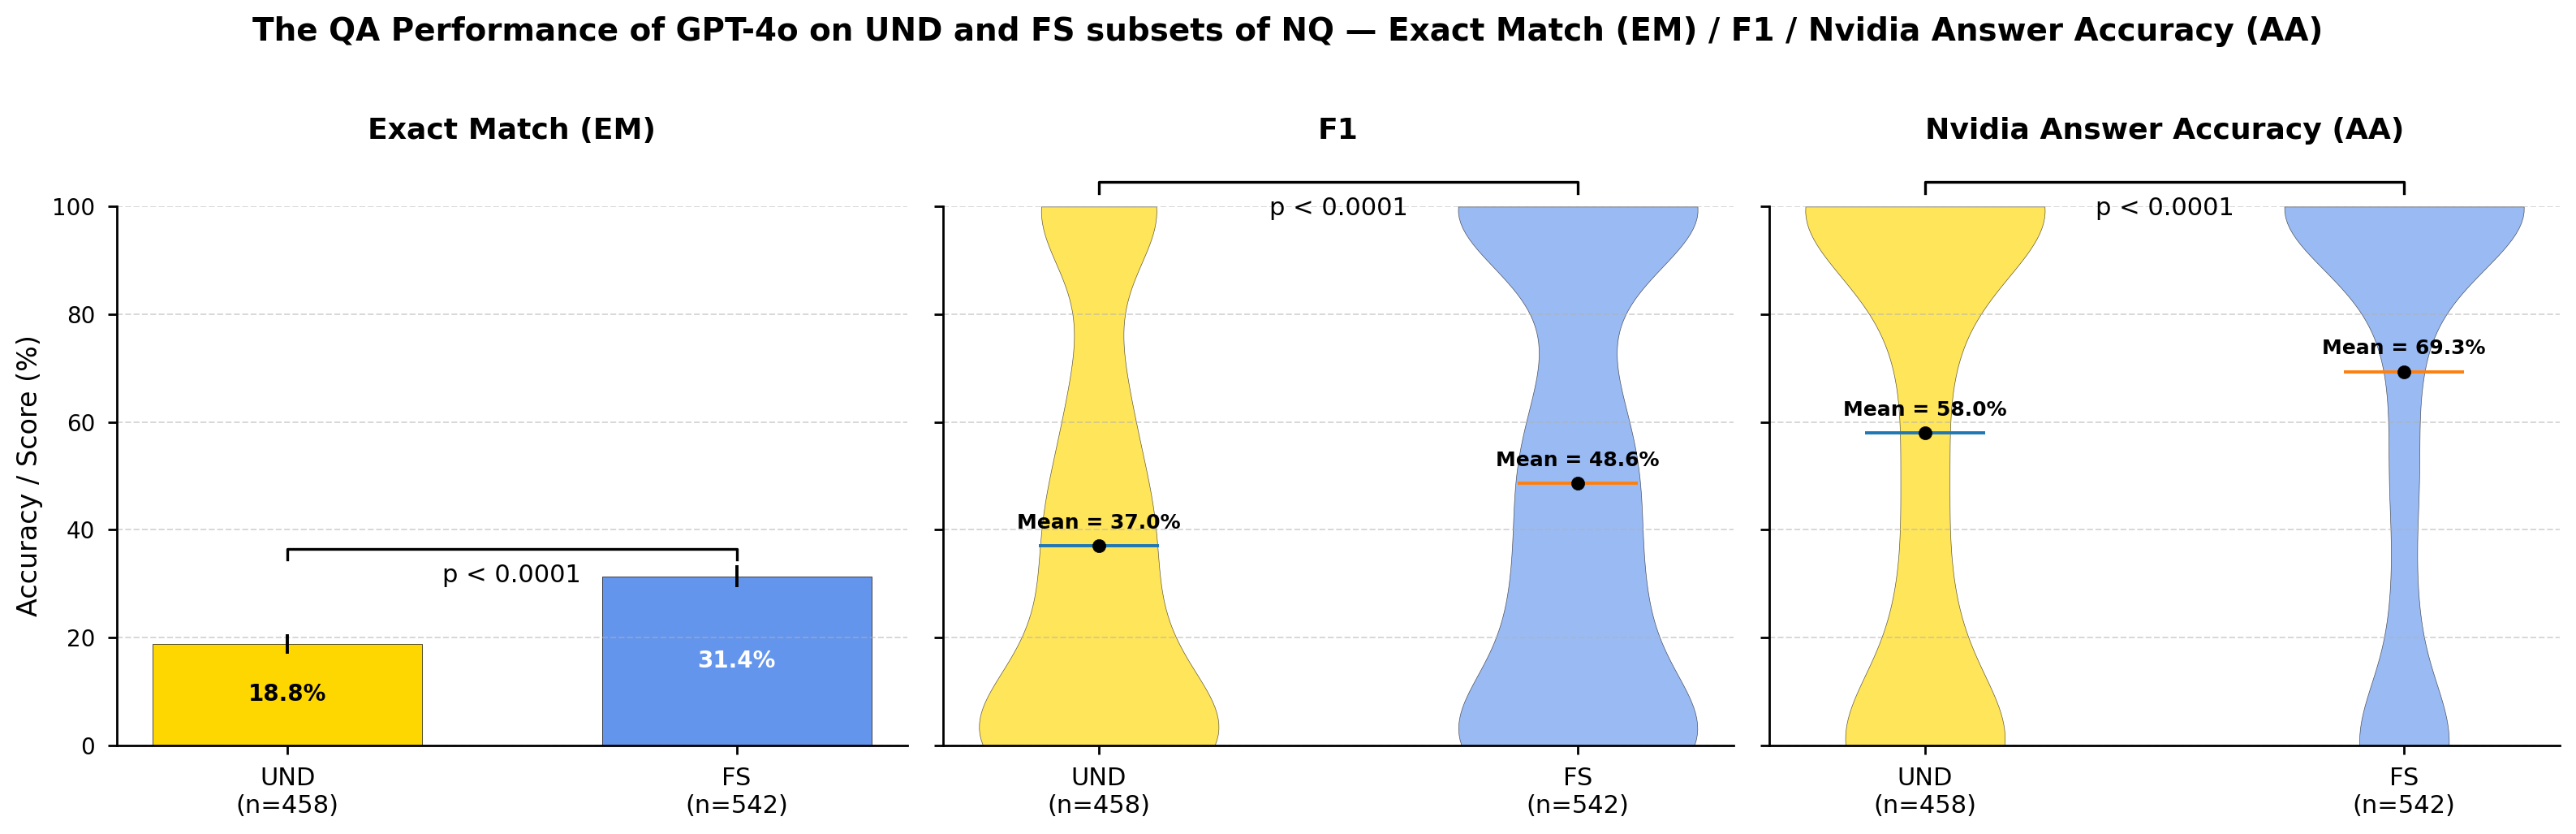

In [51]:
produce_em_f1_AA_plots('GoogleNQ_UND_gpt4o_Ragas', 'GoogleNQ_FS_gpt4o_Ragas', 'GPT-4o', 'NQ', 'p < 0.0001', 'p < 0.0001', 'p < 0.0001', 40.0)

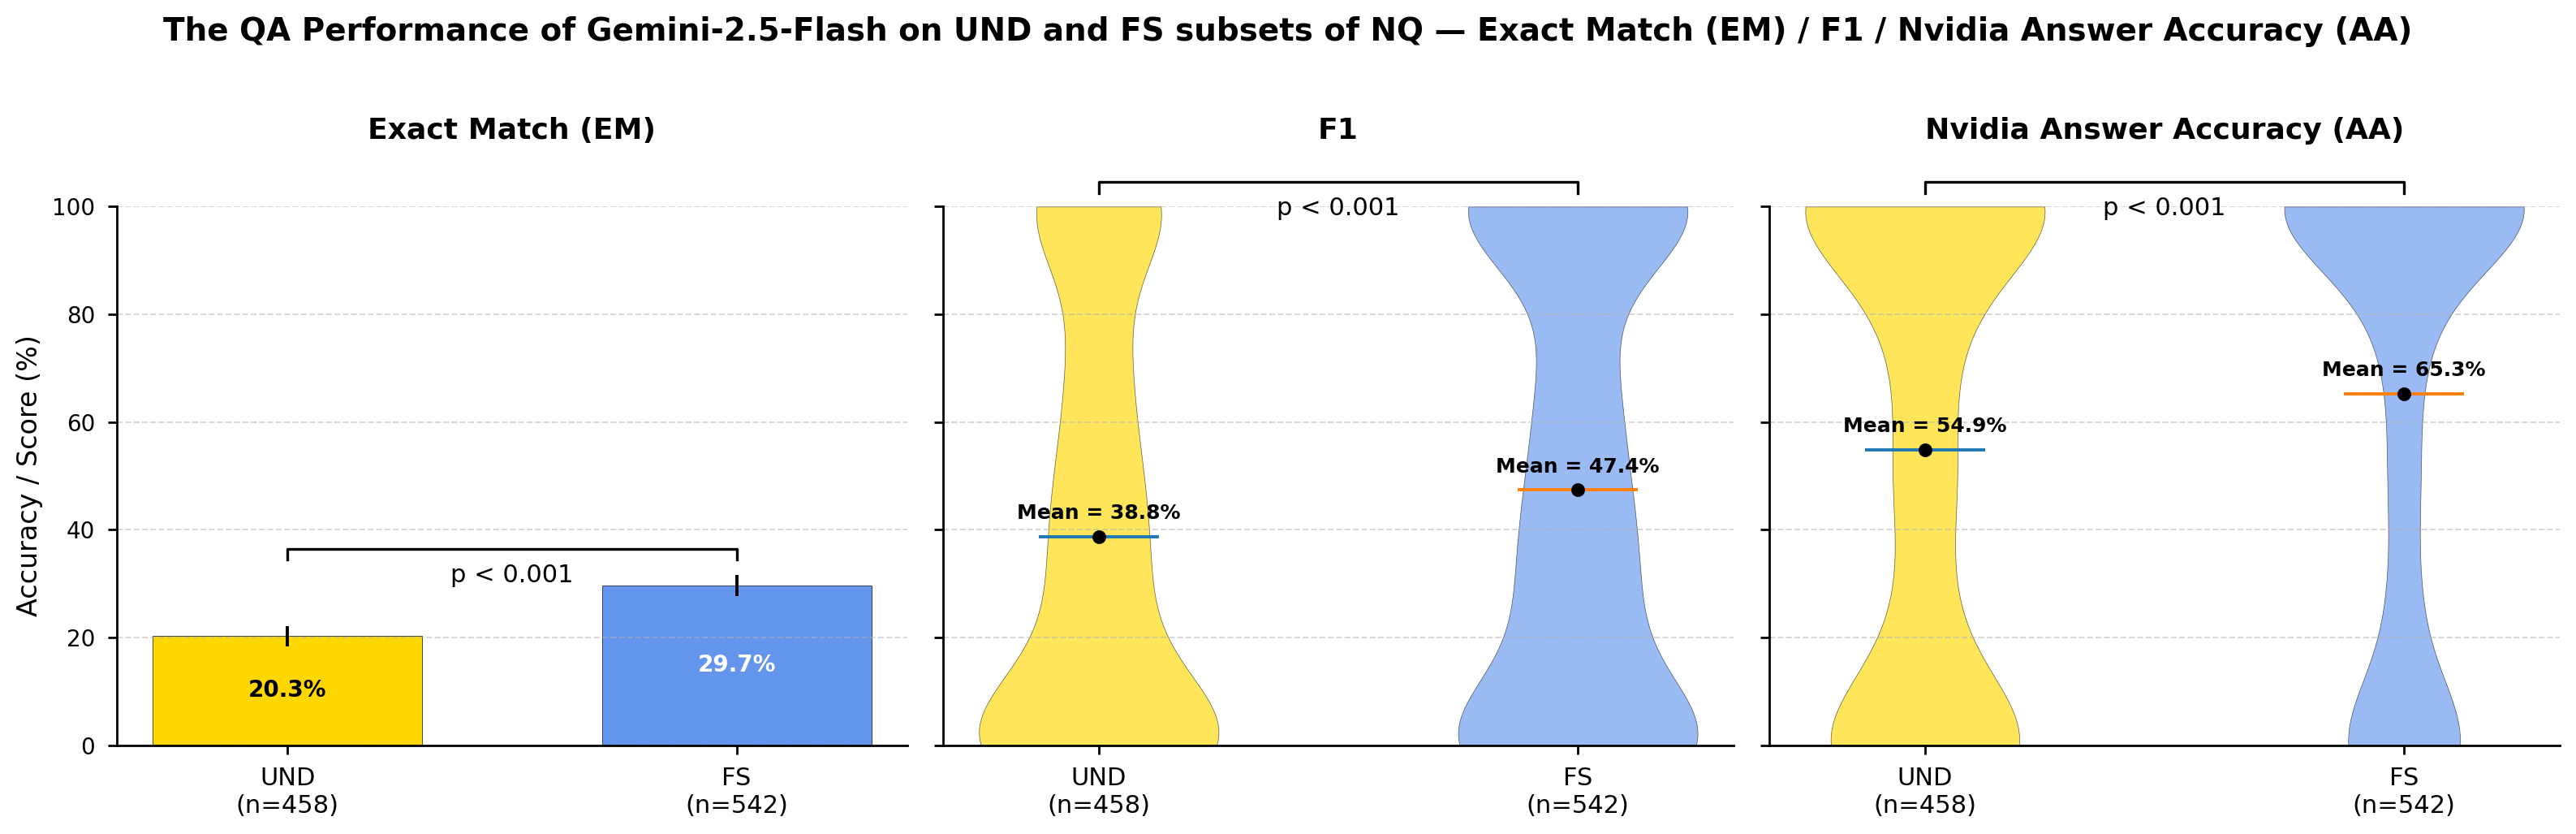

In [52]:
produce_em_f1_AA_plots('GoogleNQ_UND_Gemini_Ragas', 'GoogleNQ_FS_Gemini_Ragas', 'Gemini-2.5-Flash', 'NQ', 'p < 0.001', 'p < 0.001', 'p < 0.001', 40.0)

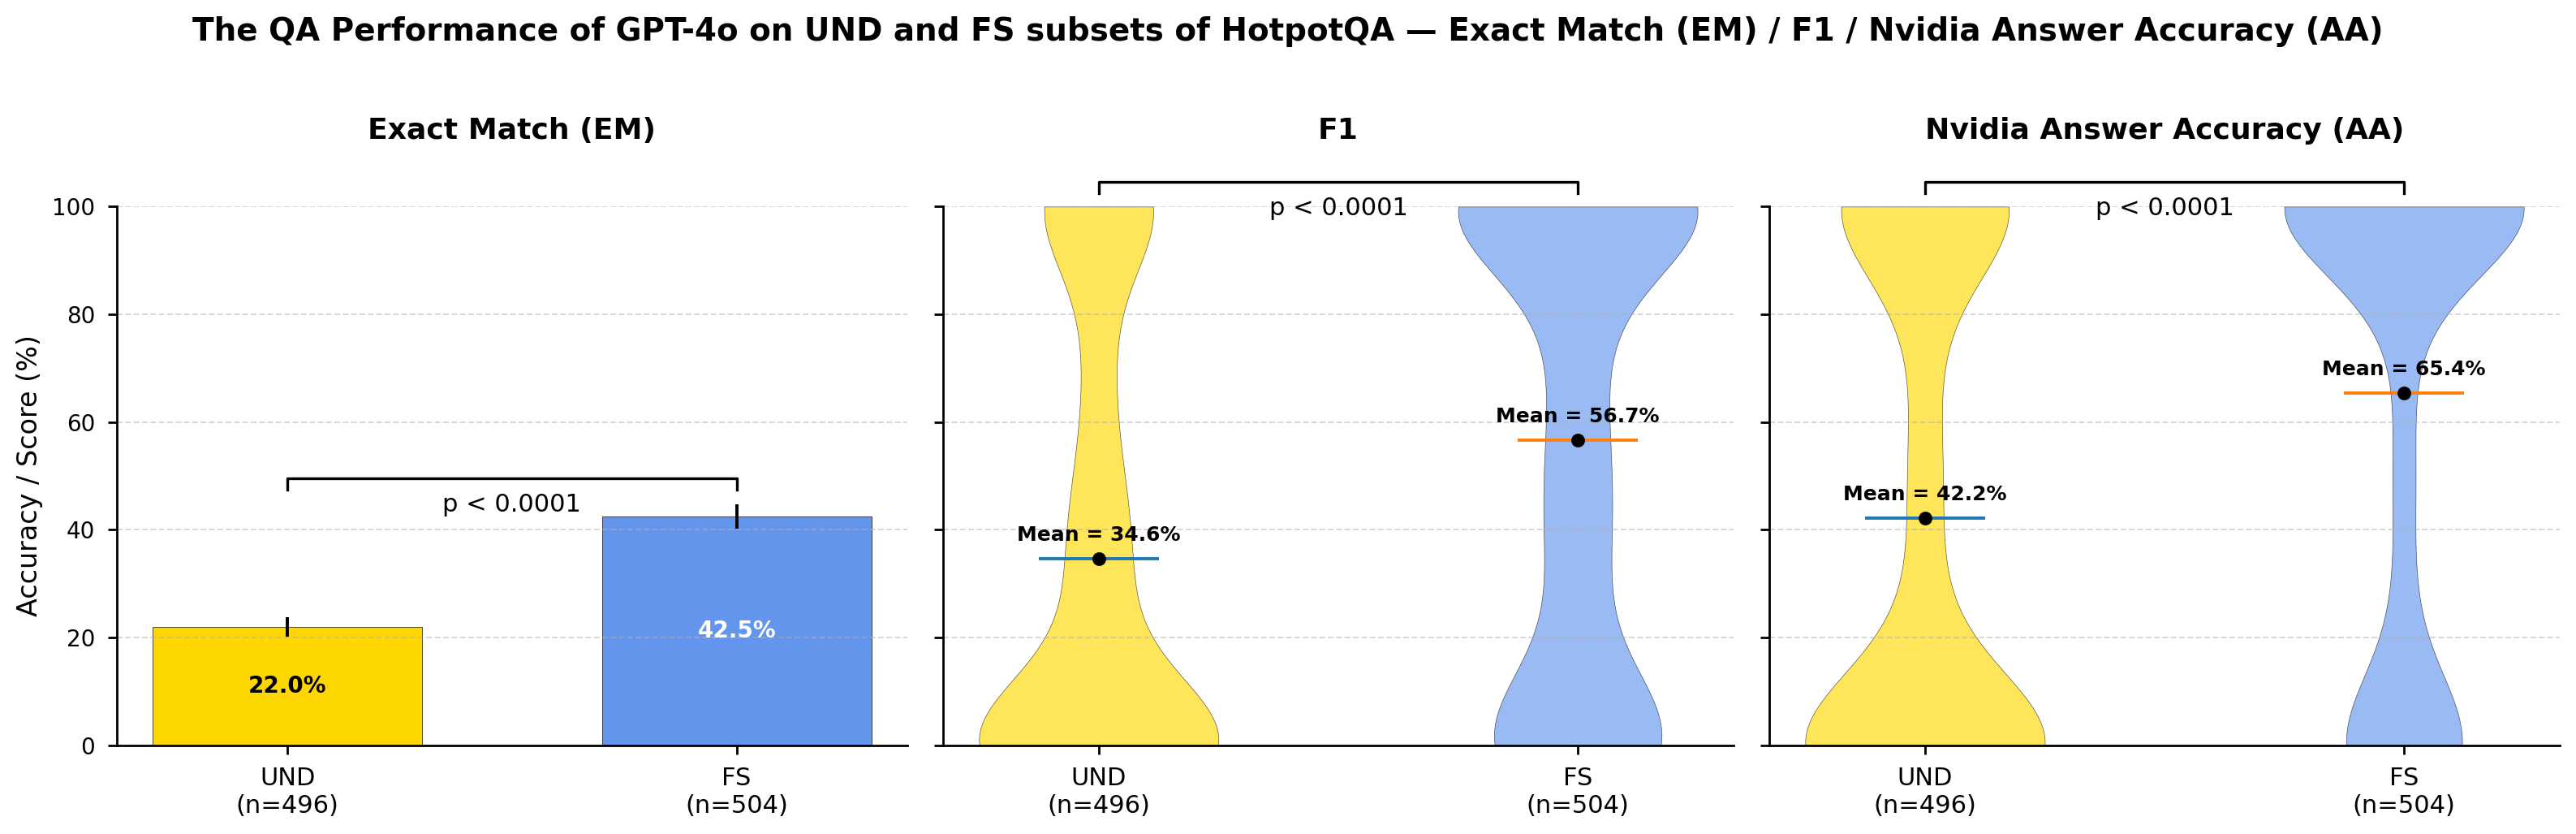

In [53]:
produce_em_f1_AA_plots('HotpotQA_UND_gpt4o_Ragas', 'HotpotQA_FS_gpt4o_Ragas', 'GPT-4o', 'HotpotQA', 'p < 0.0001', 'p < 0.0001', 'p < 0.0001', 53.0)

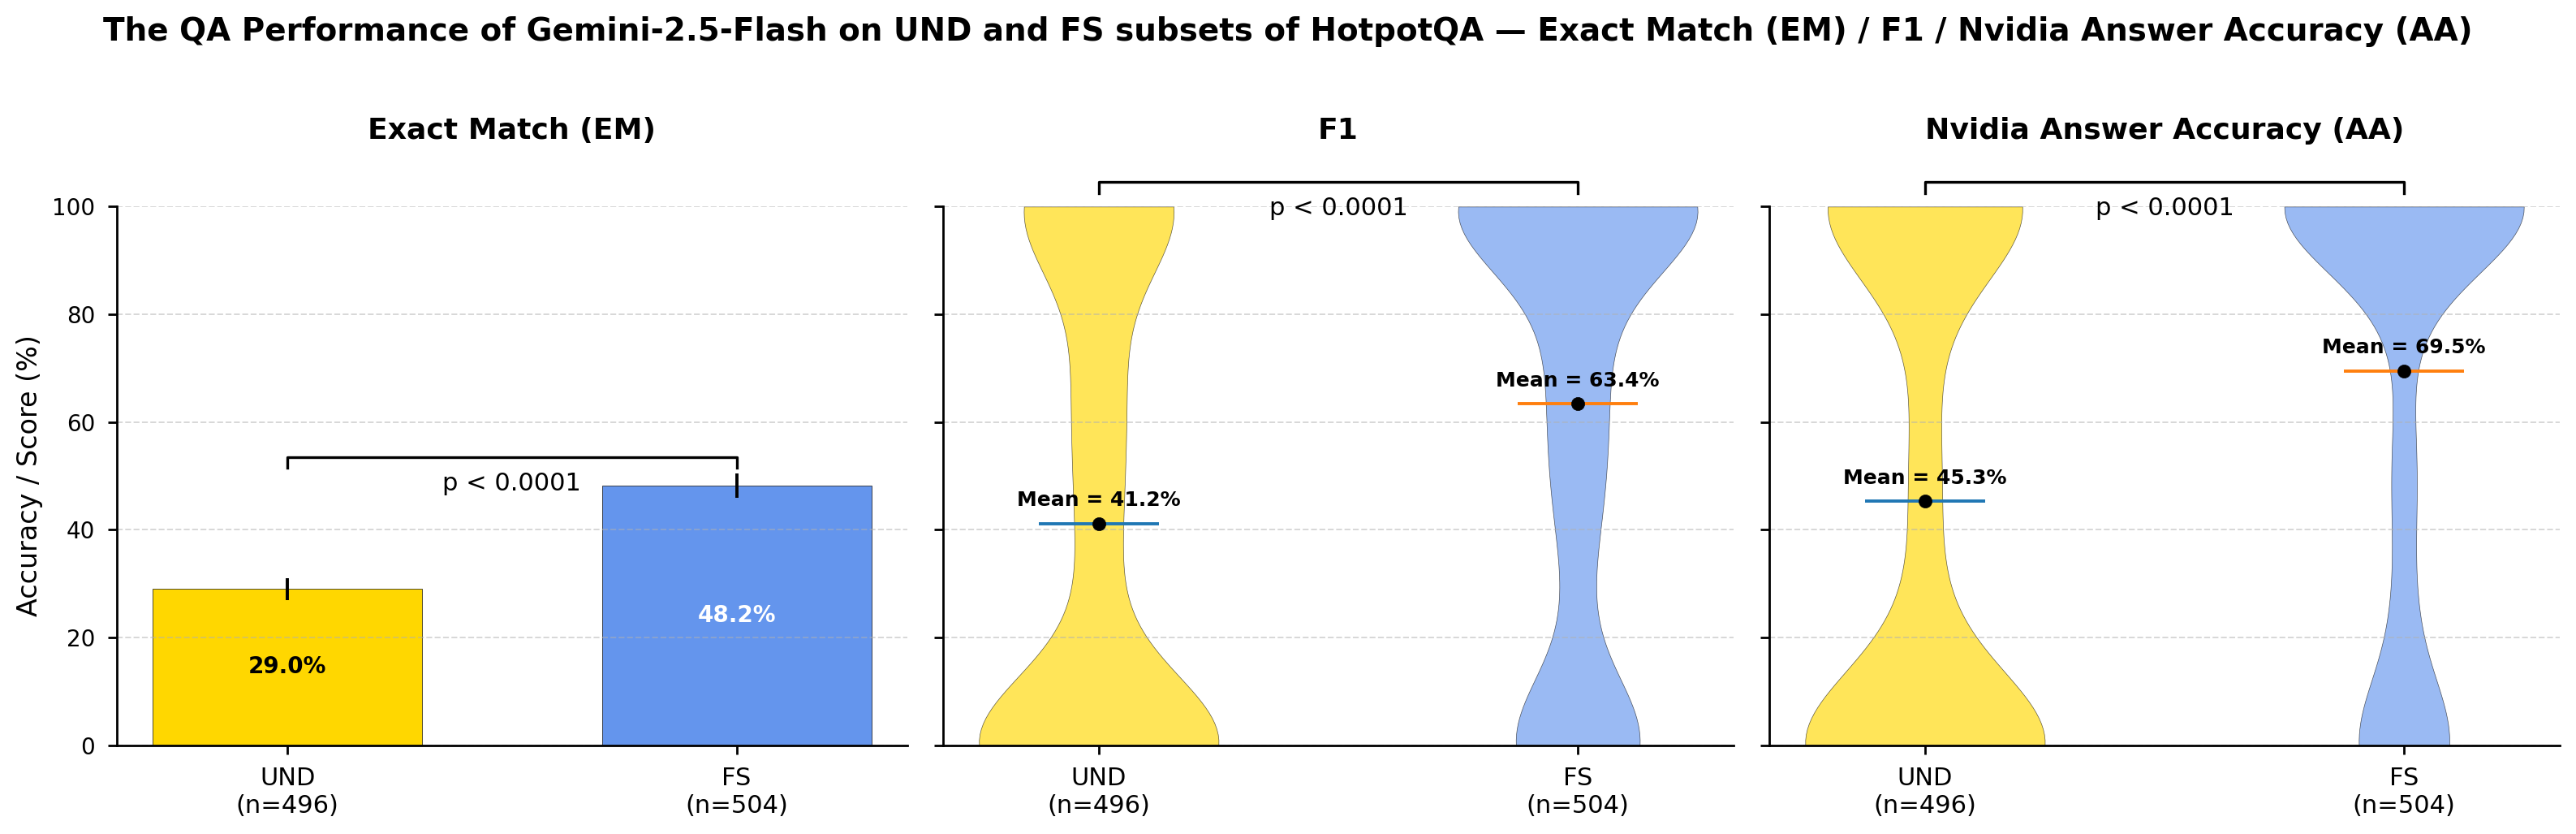

In [54]:
produce_em_f1_AA_plots('HotpotQA_UND_Gemini_Ragas', 'HotpotQA_FS_Gemini_Ragas', 'Gemini-2.5-Flash', 'HotpotQA', 'p < 0.0001', 'p < 0.0001', 'p < 0.0001', 57.0)

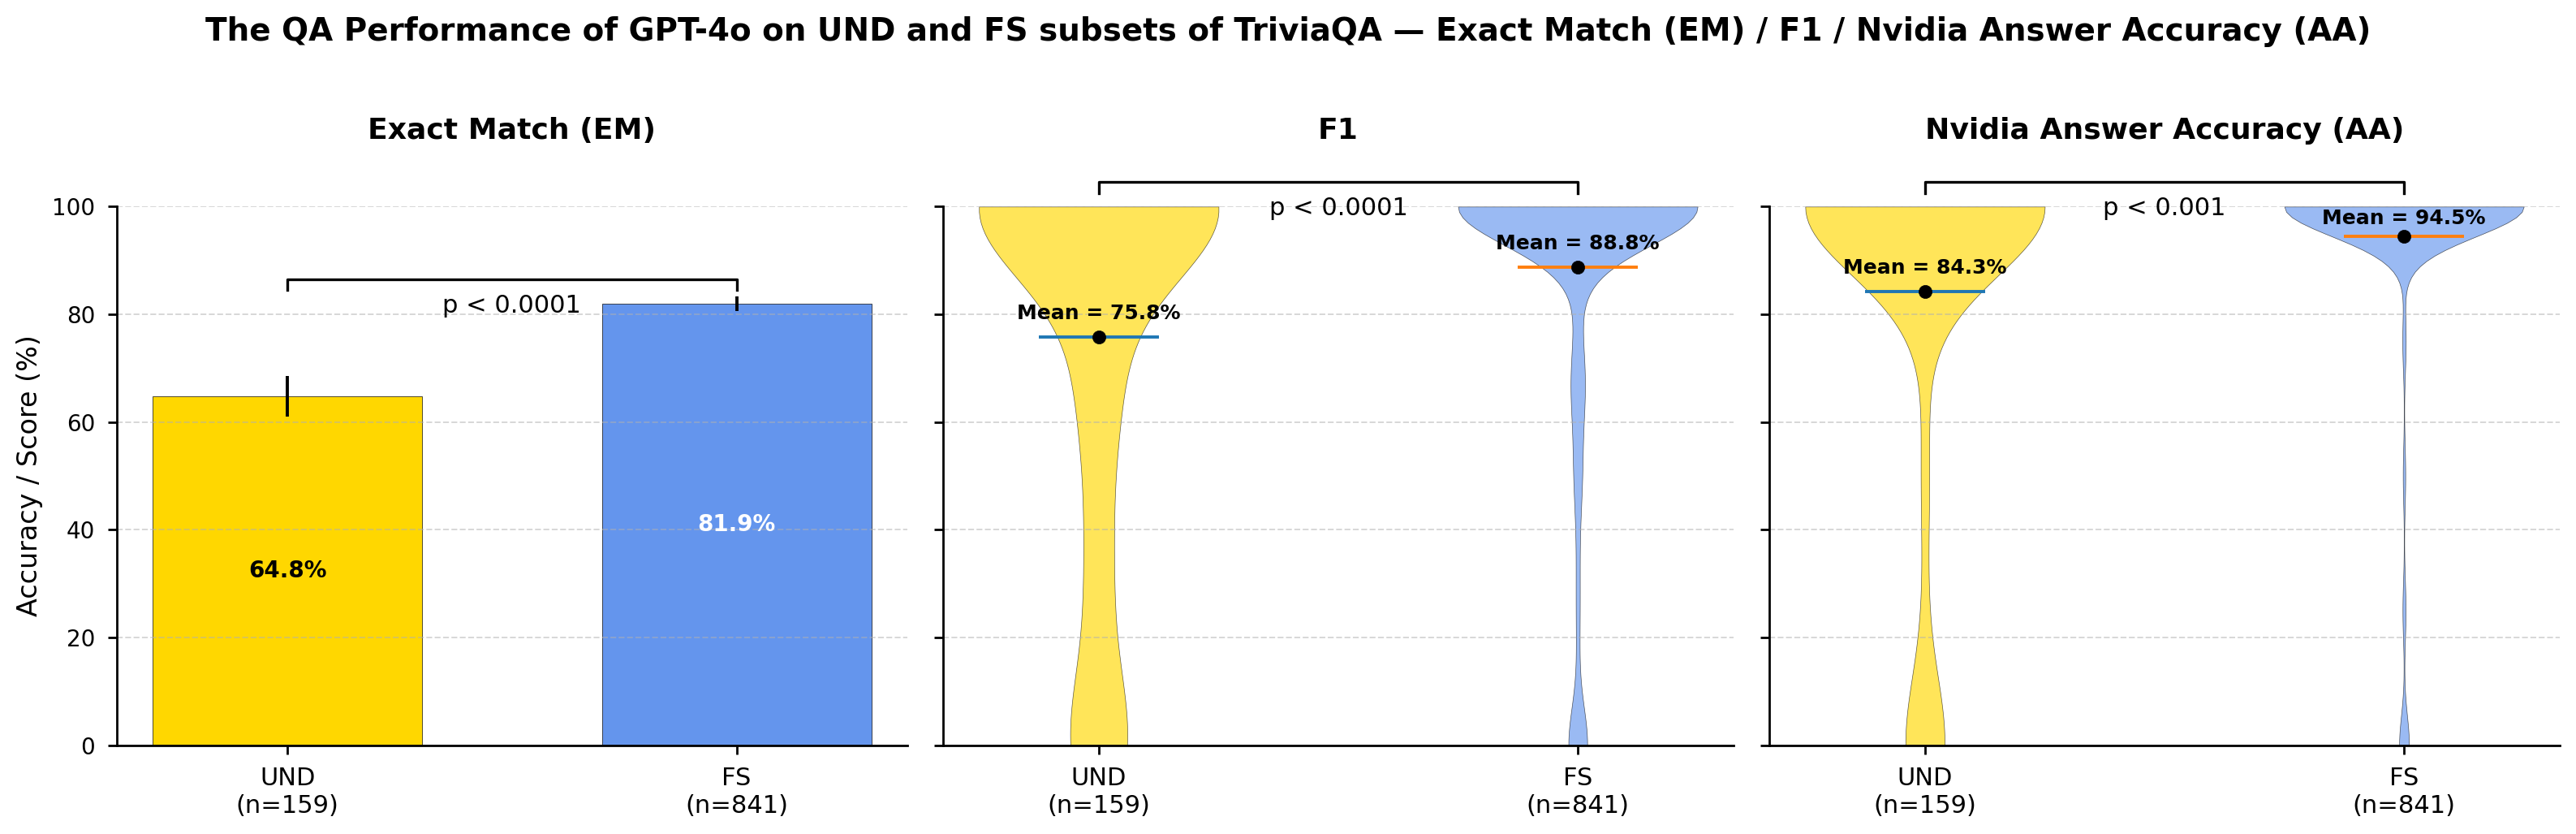

In [55]:
produce_em_f1_AA_plots('TriviaQA_UND_gpt4o_Ragas', 'TriviaQA_FS_gpt4o_Ragas', 'GPT-4o', 'TriviaQA', 'p < 0.0001', 'p < 0.0001', 'p < 0.001', 90.0)

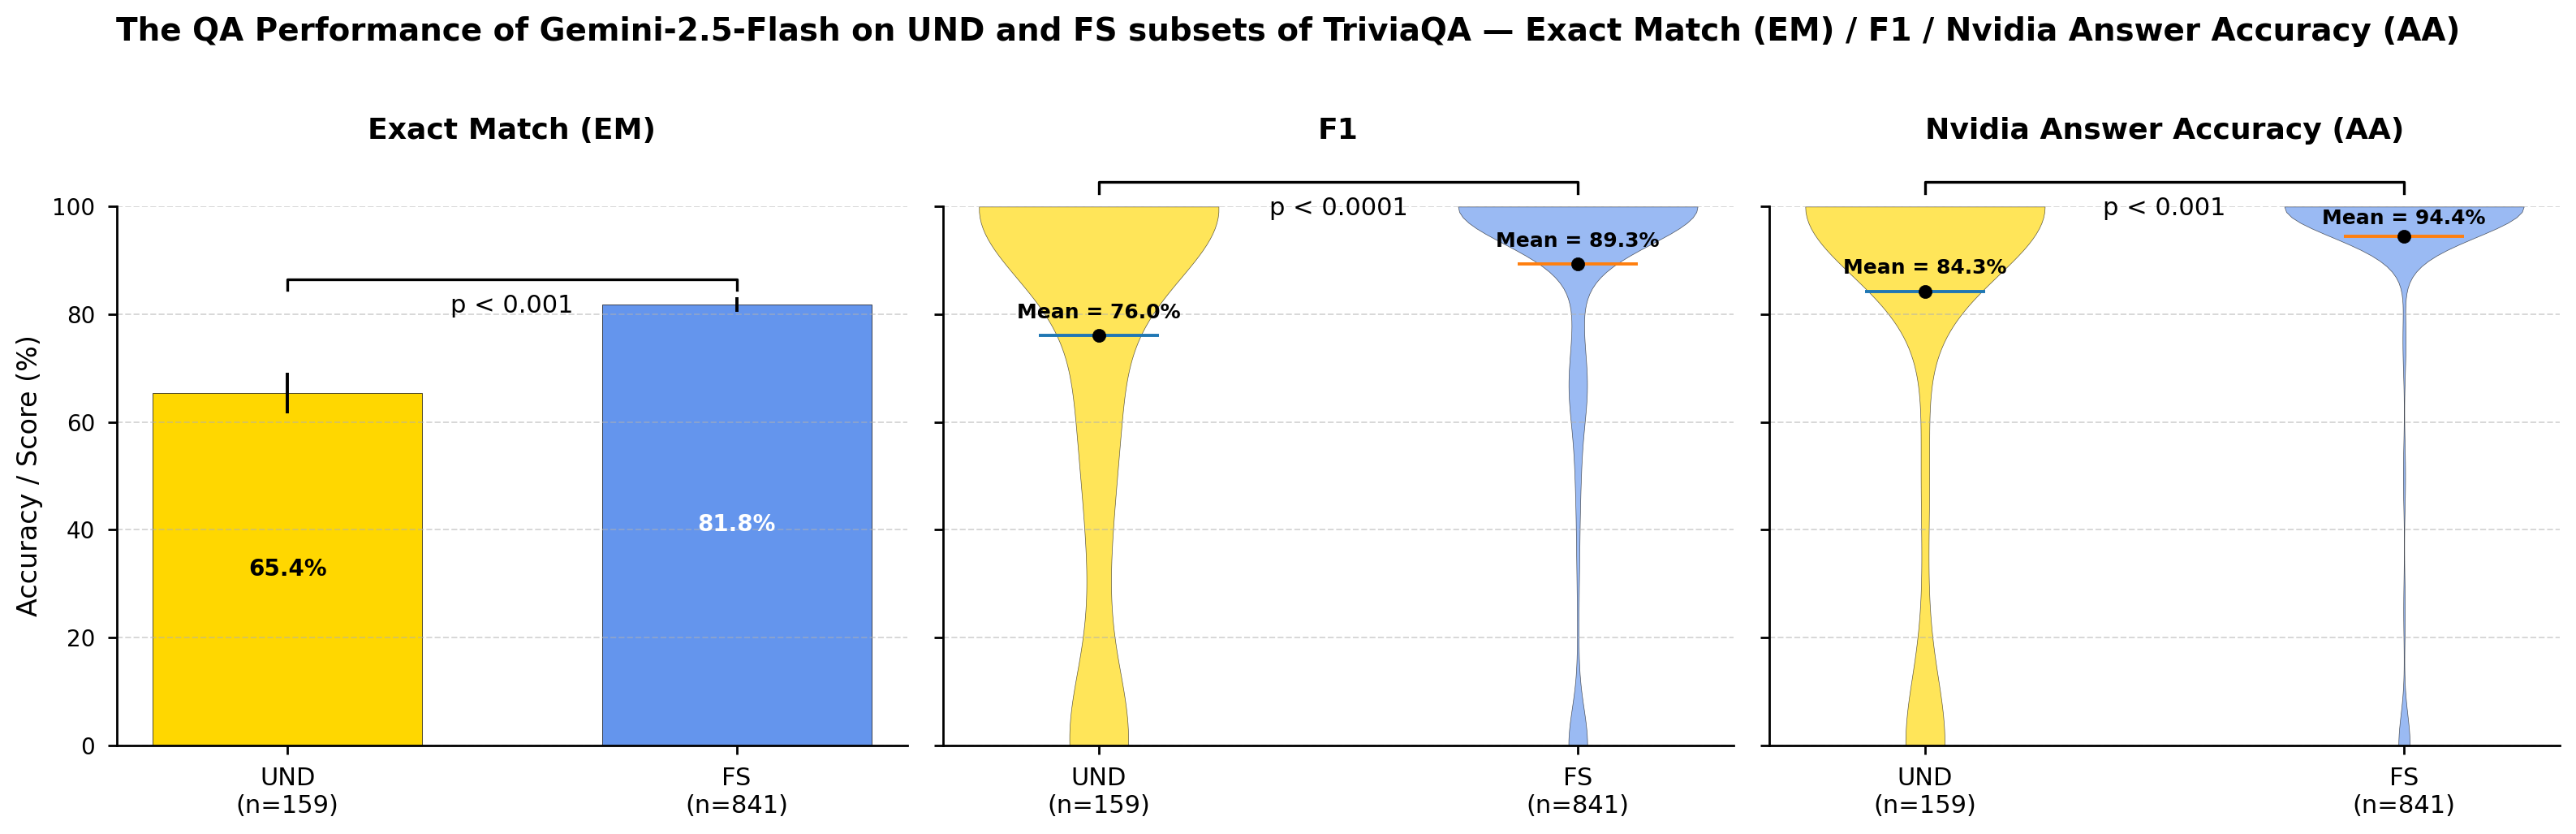

In [4]:
produce_em_f1_AA_plots('TriviaQA_UND_Gemini_Ragas', 'TriviaQA_FS_Gemini_Ragas', 'Gemini-2.5-Flash', 'TriviaQA', 'p < 0.001', 'p < 0.0001', 'p < 0.001', 90.0)

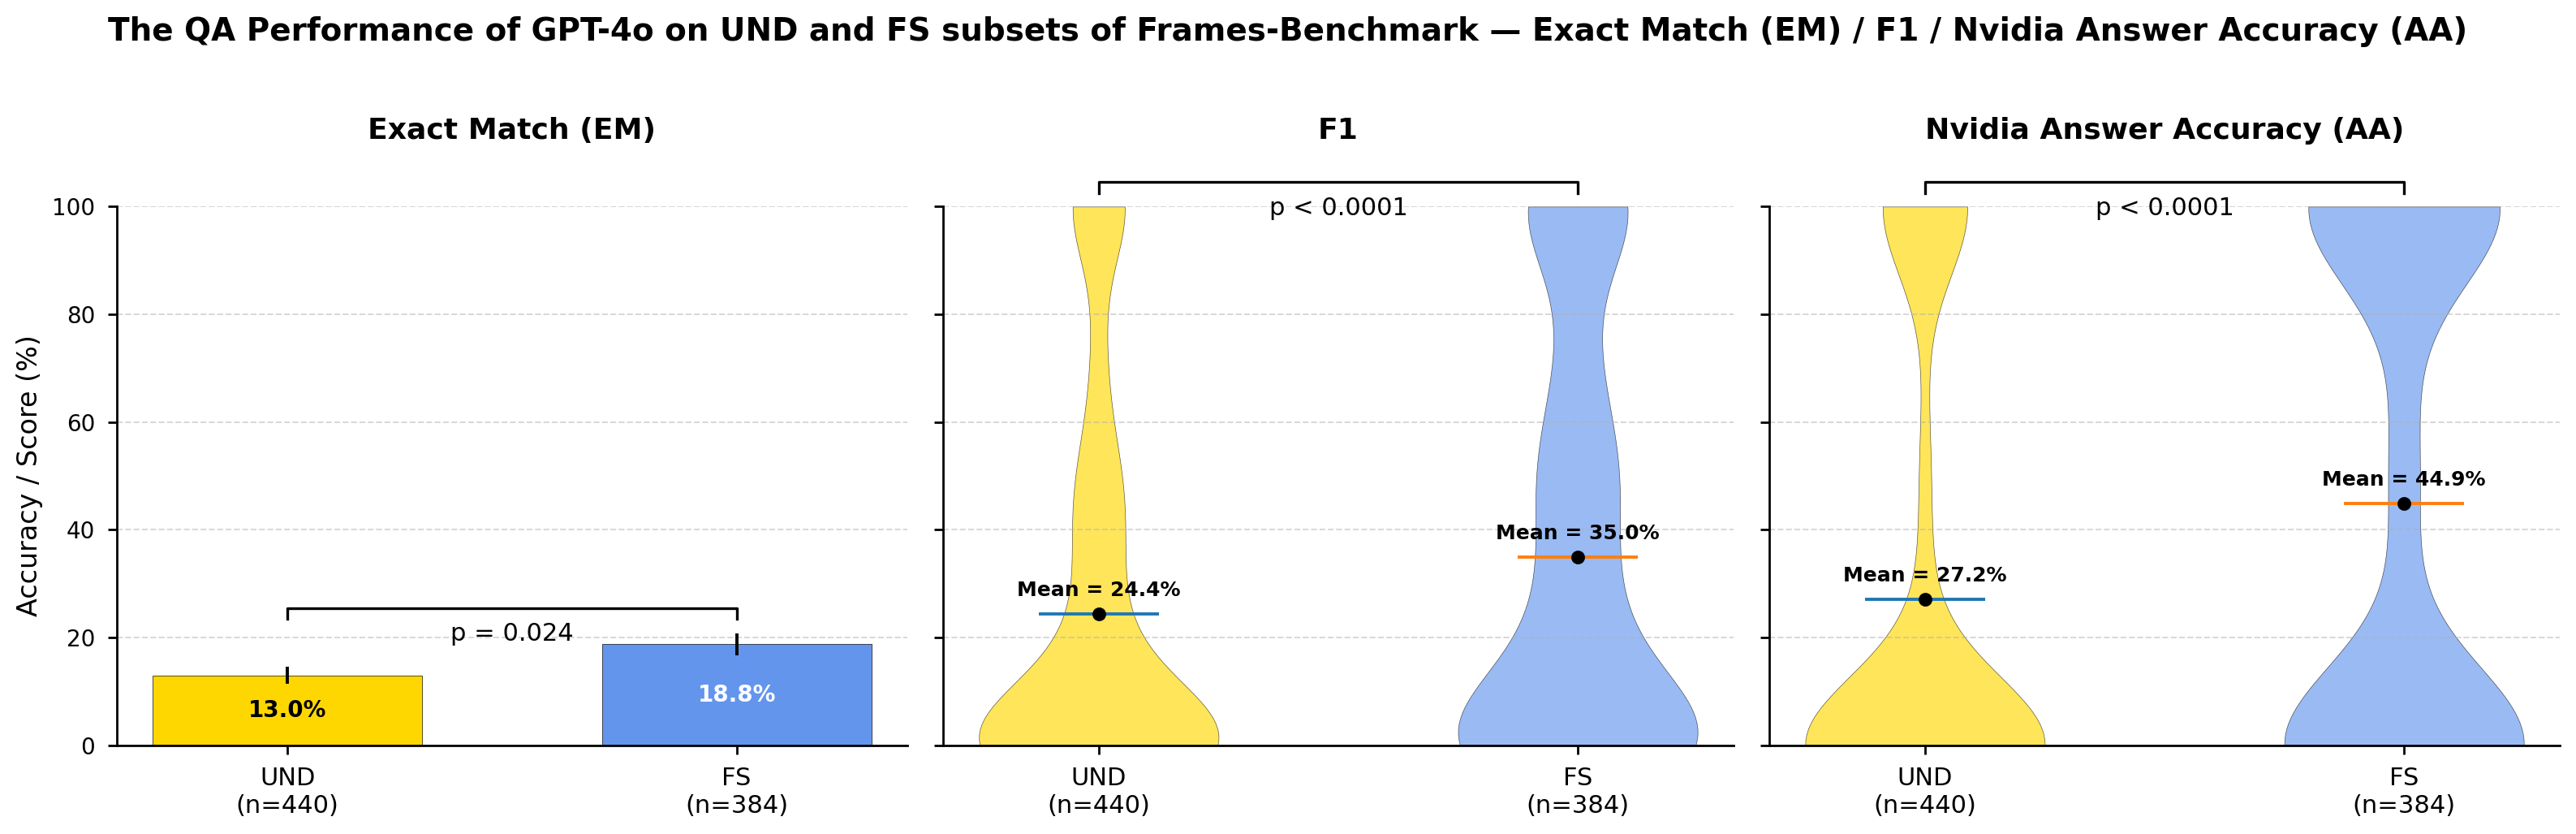

In [56]:
produce_em_f1_AA_plots('frames_UND_gpt4o_Ragas', 'frames_FS_gpt4o_Ragas', 'GPT-4o', 'Frames-Benchmark', 'p = 0.024', 'p < 0.0001', 'p < 0.0001', 29.0)

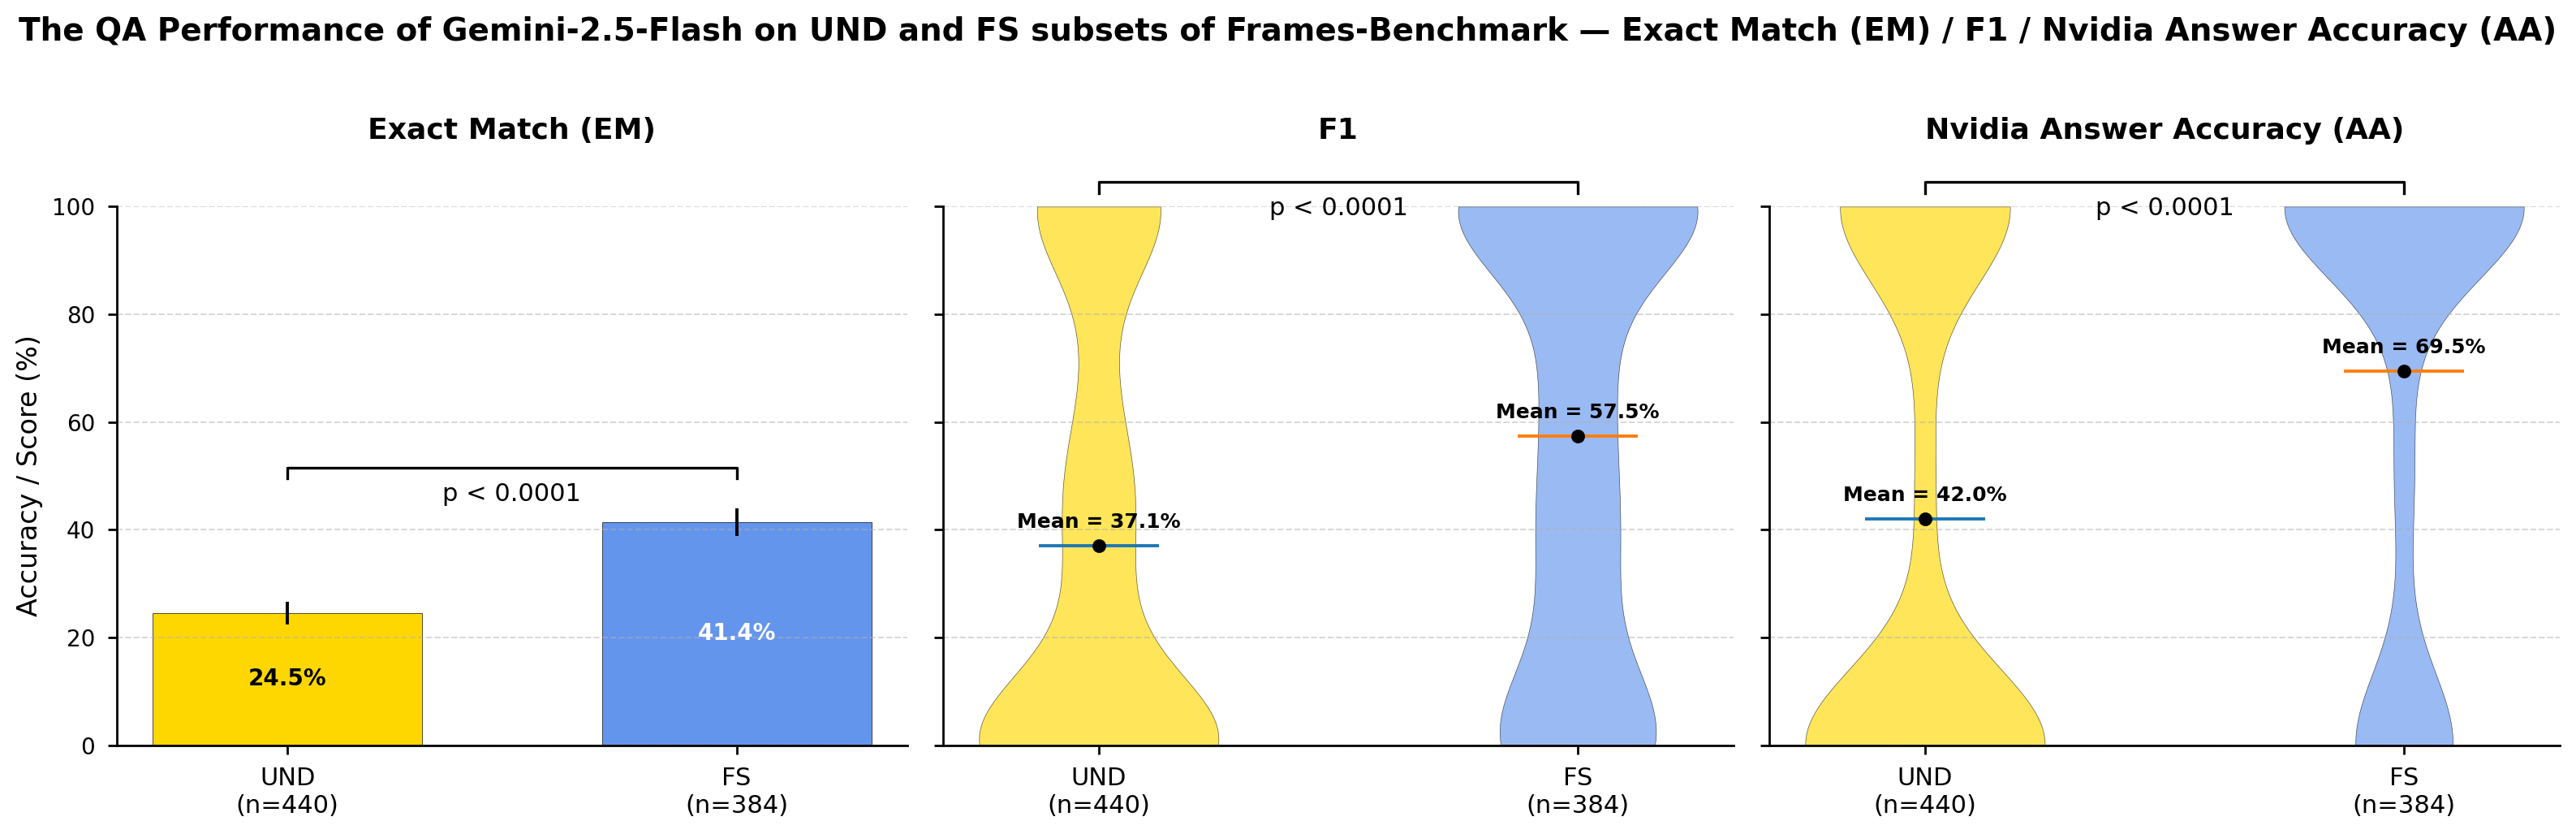

In [57]:
produce_em_f1_AA_plots('frames_UND_Gemini_Ragas', 'frames_FS_Gemini_Ragas', 'Gemini-2.5-Flash', 'Frames-Benchmark', 'p < 0.0001', 'p < 0.0001', 'p < 0.0001', 55.0)

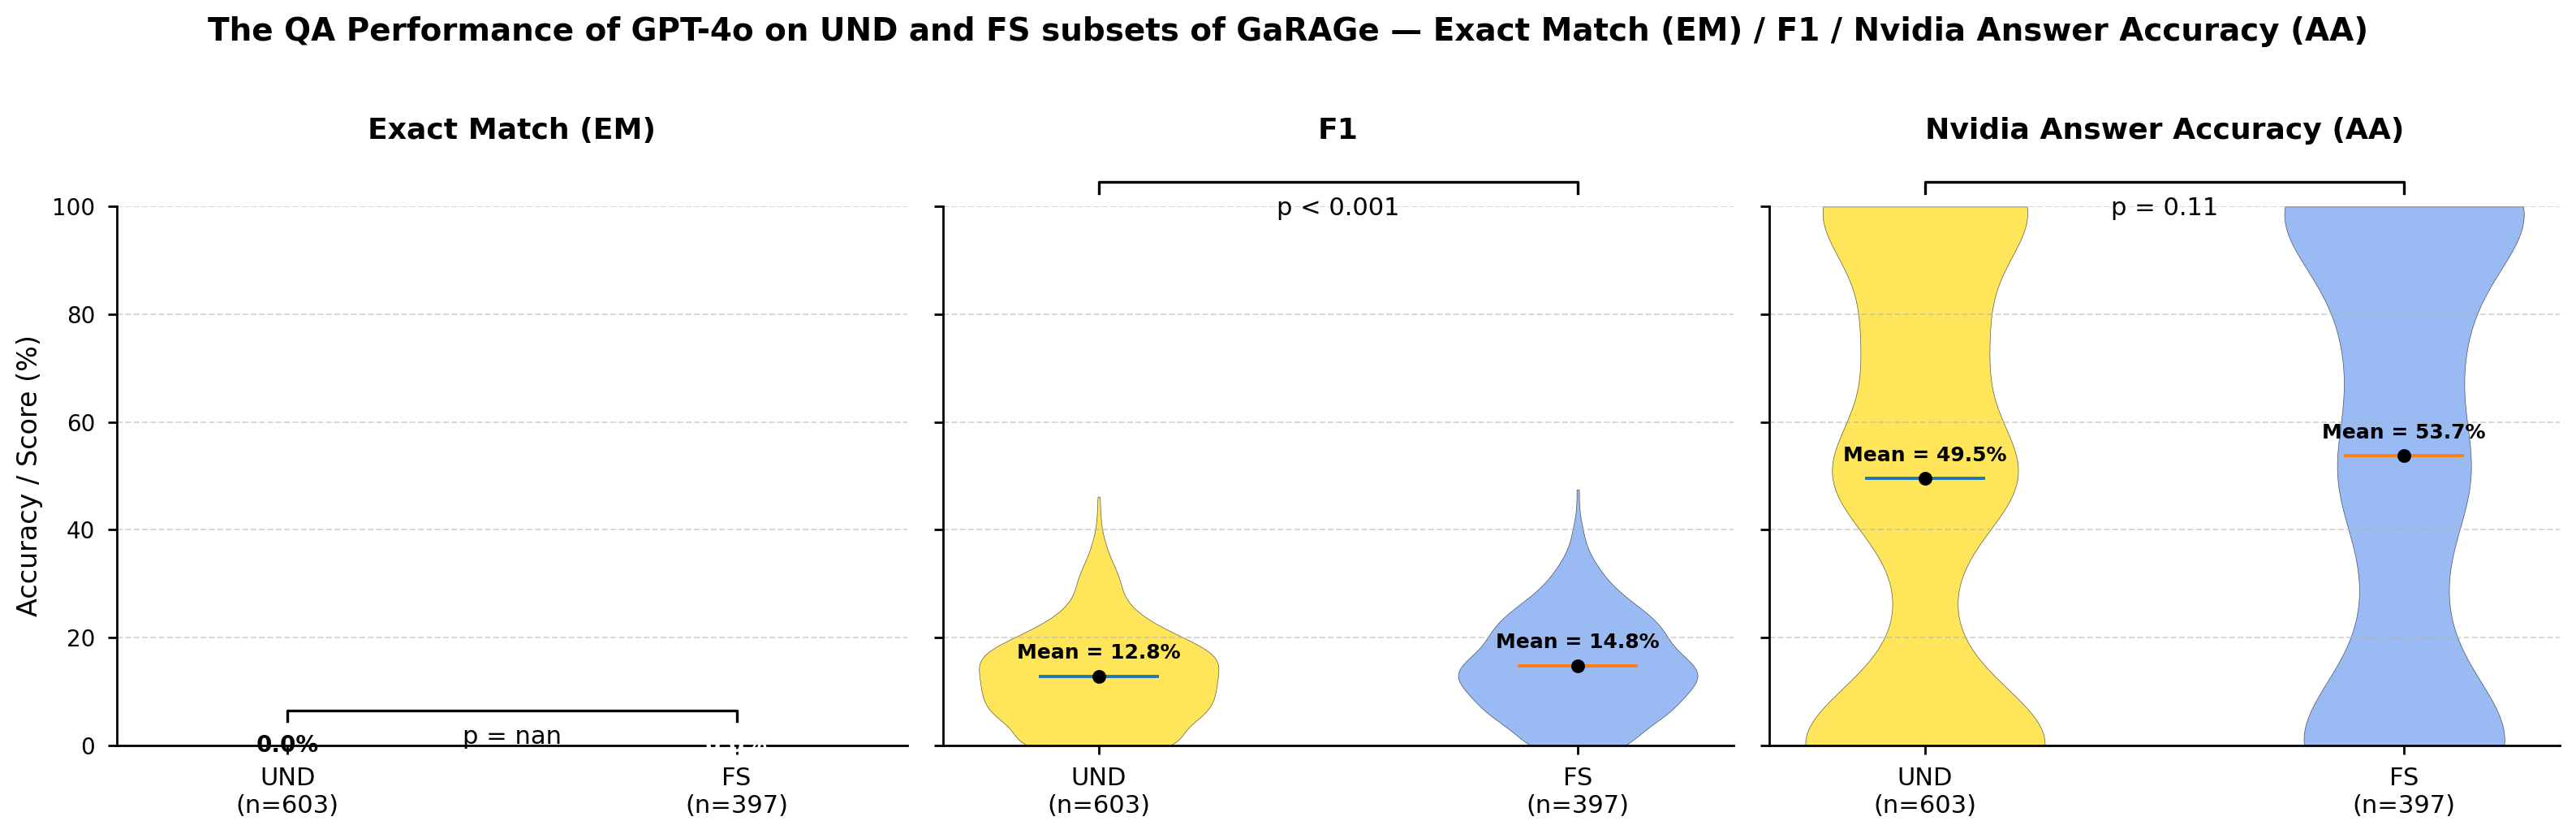

In [58]:
produce_em_f1_AA_plots('GaRAGe_UND_gpt4o_Ragas', 'GaRAGe_FS_gpt4o_Ragas', 'GPT-4o', 'GaRAGe', 'p = nan', 'p < 0.001', 'p = 0.11', 10.0)

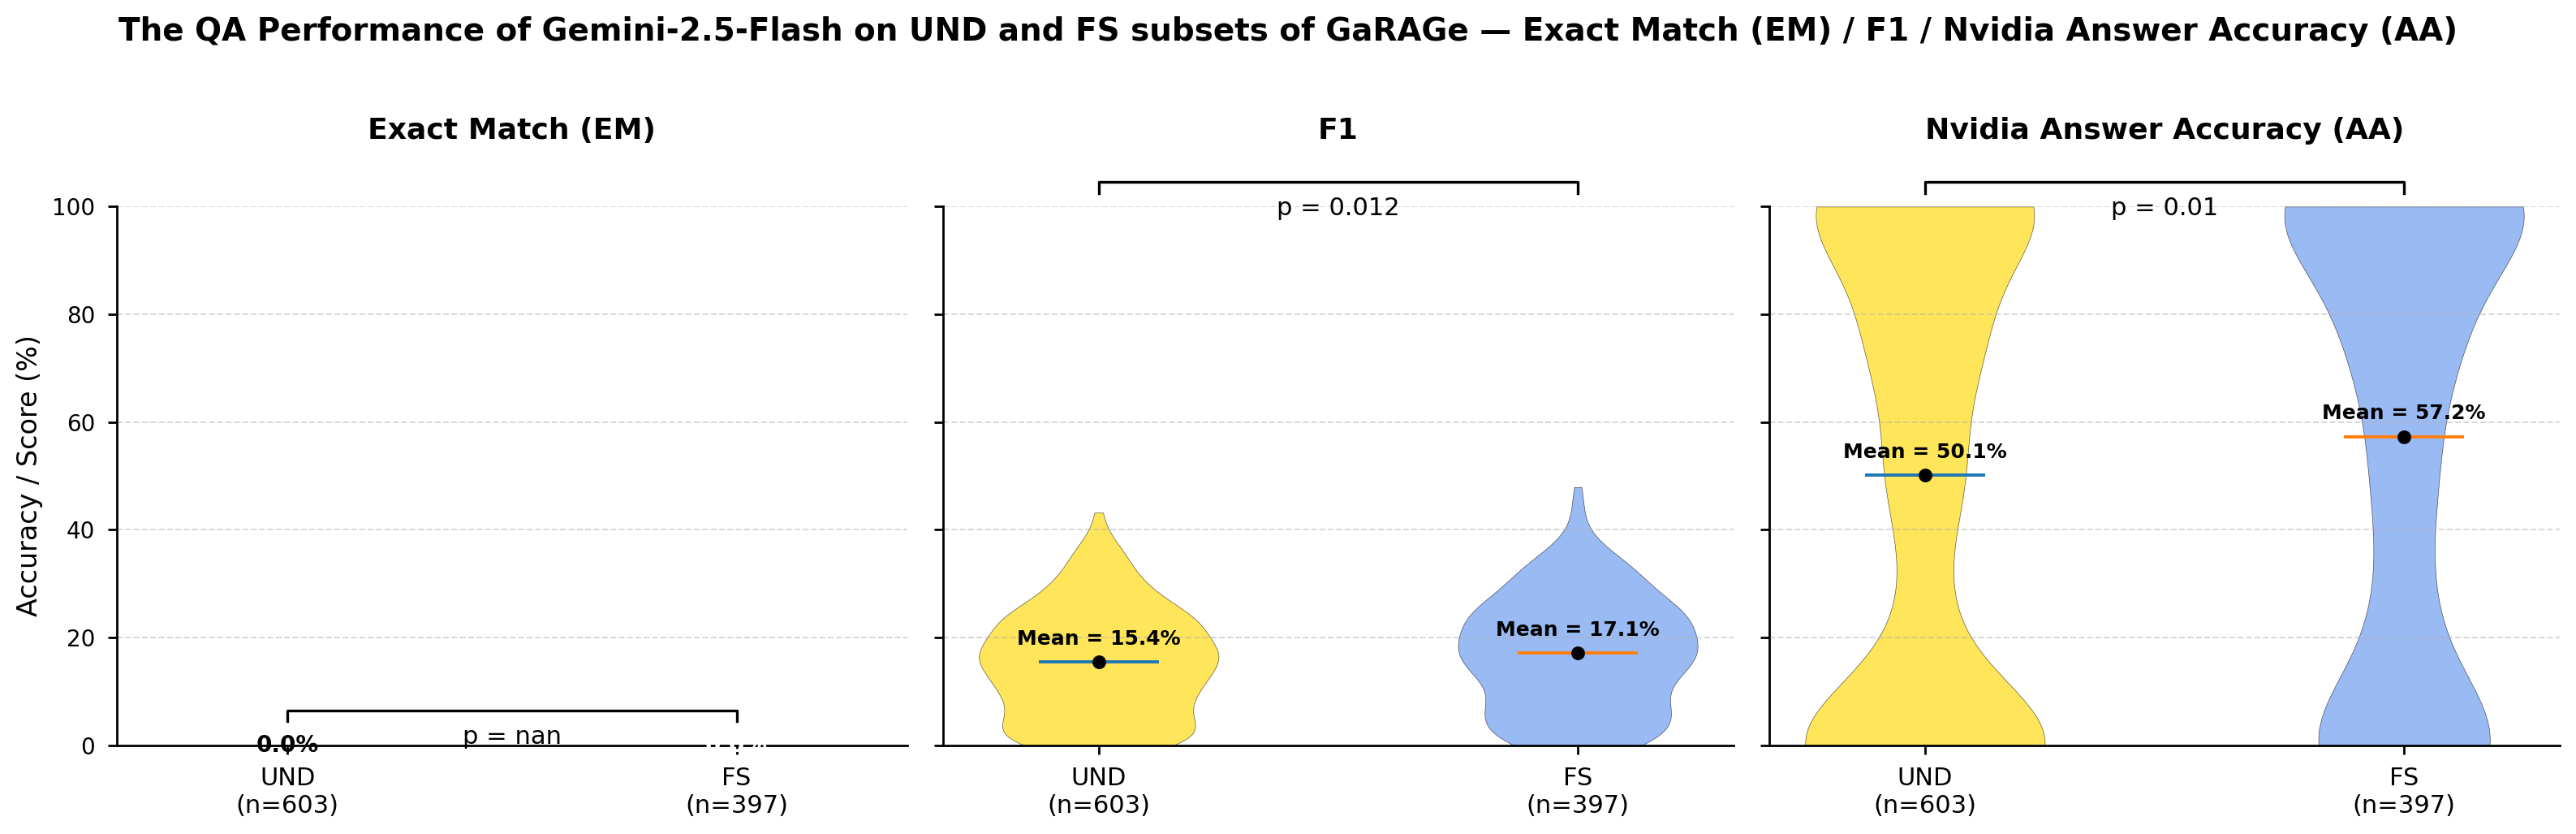

In [59]:
produce_em_f1_AA_plots('GaRAGe_UND_Gemini_Ragas', 'GaRAGe_FS_Gemini_Ragas', 'Gemini-2.5-Flash', 'GaRAGe', 'p = nan', 'p = 0.012', 'p = 0.01', 10.0)

## Special Treatments for GaRAGe

In [60]:
def to_percent_if_needed(a: np.ndarray) -> np.ndarray:
        """若数值最大不超过 1，则乘以 100 变为百分比。"""
        a = a.astype(float)
        if np.nanmax(a) <= 1.0:
            a = a * 100.0
        return a

def sem(a: np.ndarray) -> float:
    a = a.astype(float)
    return float(np.nanstd(a, ddof=1) / np.sqrt(np.sum(~np.isnan(a))))

def add_pvalue_bracket(ax, text, x1=1.0, x2=2.0,
                       y_top=100.0, inset=5.0, height=2.0,
                       text_x=None, text_dy=0.6, lw=1.2):
    """
    在 y_top 下方画“∪”形括号，p 值文字在括号下方（适合 0-100% 纵轴）。
    x1/x2 是两组的横坐标（与 set_xticks 对齐），y_top 是图顶参考值（可略高于 ylim 上限），
    inset 控制括号整体下移，height 控制括号高度。
    """
    y_base = y_top - inset
    y_top_line = y_base + height
    if text_x is None:
        text_x = (x1 + x2) / 2.0
    ax.plot([x1, x1, x2, x2],
            [y_base, y_top_line, y_top_line, y_base],
            lw=lw, c="black", clip_on=False)
    ax.text(text_x, y_base - text_dy, text,
            ha="center", va="top", fontsize=11, clip_on=False)

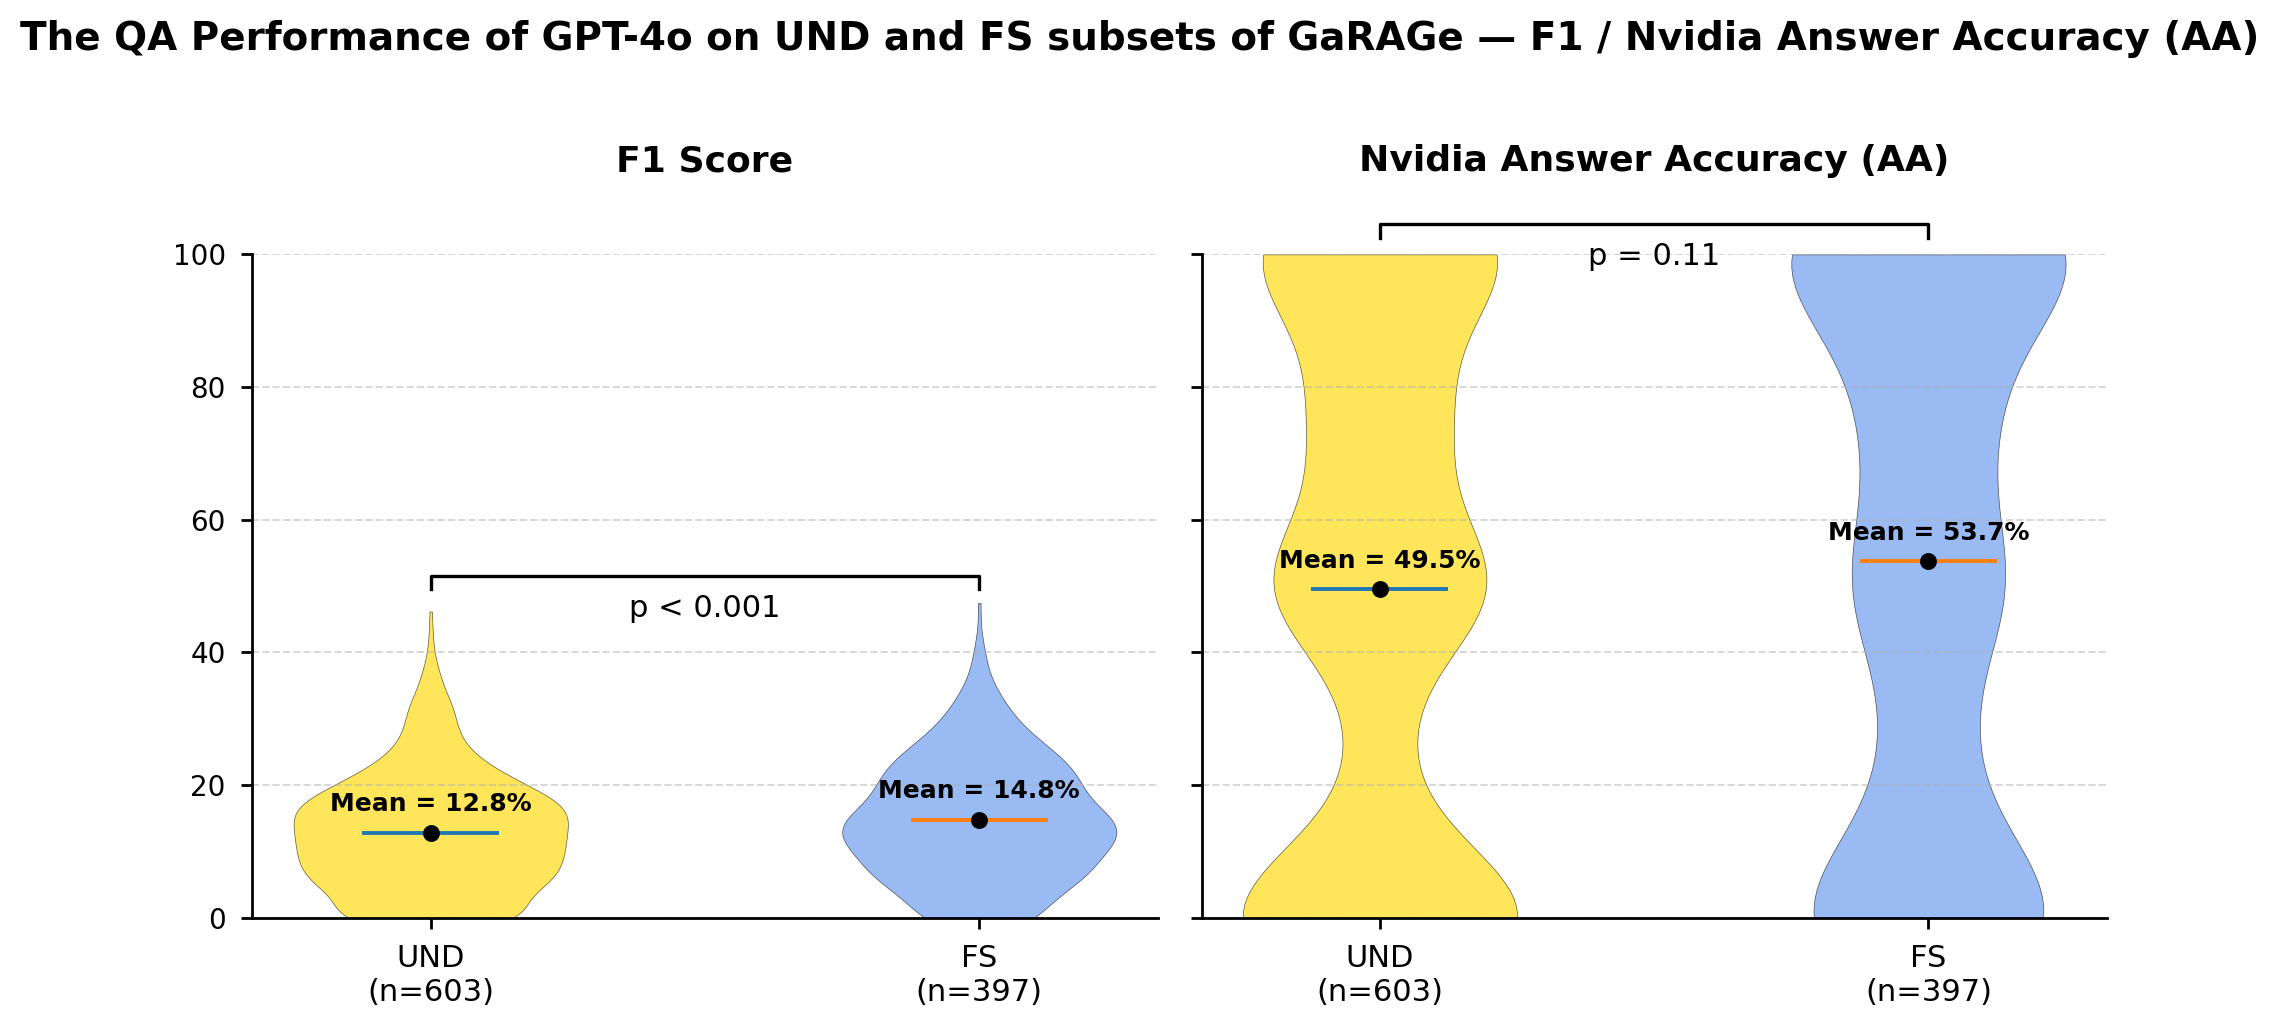

In [61]:
# Results from GPT-4o

und_path = "./output_csv/GaRAGe_UND_gpt4o_Ragas.csv"
fs_path  = "./output_csv/GaRAGe_FS_gpt4o_Ragas.csv"

COLORS = ["#FFD700", "#6495ED"]  # UND / FS
LABELS = ["UND", "FS"]

UND = pd.read_csv(und_path)
FS  = pd.read_csv(fs_path)

# 2) F1
und_f1 = to_percent_if_needed(UND["f1"].dropna().values)
fs_f1  = to_percent_if_needed(FS["f1"].dropna().values)
f1_ns  = [len(und_f1), len(fs_f1)]

# 3) RAGAS AA short
und_aa = to_percent_if_needed(UND["ragas_AA_short"].dropna().values)
fs_aa  = to_percent_if_needed(FS["ragas_AA_short"].dropna().values)
aa_ns  = [len(und_aa), len(fs_aa)]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax1, ax2 = axes

# ---- 左：F1 小提琴图 ----
for i, (vals, color) in enumerate(zip([und_f1, fs_f1], COLORS), start=1):
    parts = ax1.violinplot(vals, positions=[i],
                           showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    # 均值点与标签
    m = float(np.mean(vals))
    ax1.scatter(i, m, s=34, color="black", zorder=3)
    ax1.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_xticks([1, 2])
ax1.set_xticklabels([f"UND\n(n={f1_ns[0]})", f"FS\n(n={f1_ns[1]})"], fontsize=11)
ax1.set_title("F1 Score", fontsize=13, weight="bold", pad=30)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_ylim(0, 100)
add_pvalue_bracket(ax1, text="p < 0.001",
                   x1=1.0, x2=2.0,
                   y_top=55.0, inset=5.5, height=2.0,
                   text_x=1.5, text_dy=0.7)

# ---- 右：RAGAS AA (short) 小提琴图 ----
for i, (vals, color) in enumerate(zip([und_aa, fs_aa], COLORS), start=1):
    parts = ax2.violinplot(vals, positions=[i],
                        showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    m = float(np.mean(vals))
    ax2.scatter(i, m, s=34, color="black", zorder=3)
    ax2.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_xticks([1, 2])
ax2.set_xticklabels([f"UND\n(n={aa_ns[0]})", f"FS\n(n={aa_ns[1]})"], fontsize=11)
ax2.set_title("Nvidia Answer Accuracy (AA)", fontsize=13, weight="bold", pad=30)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 100)
add_pvalue_bracket(ax2, text="p = 0.11",
                x1=1.0, x2=2.0,
                y_top=108.0, inset=5.5, height=2.0,
                text_x=1.5, text_dy=0.7)

# ---- 总标题与布局 ----
fig.suptitle("The QA Performance of GPT-4o on UND and FS subsets of GaRAGe — F1 / Nvidia Answer Accuracy (AA)", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


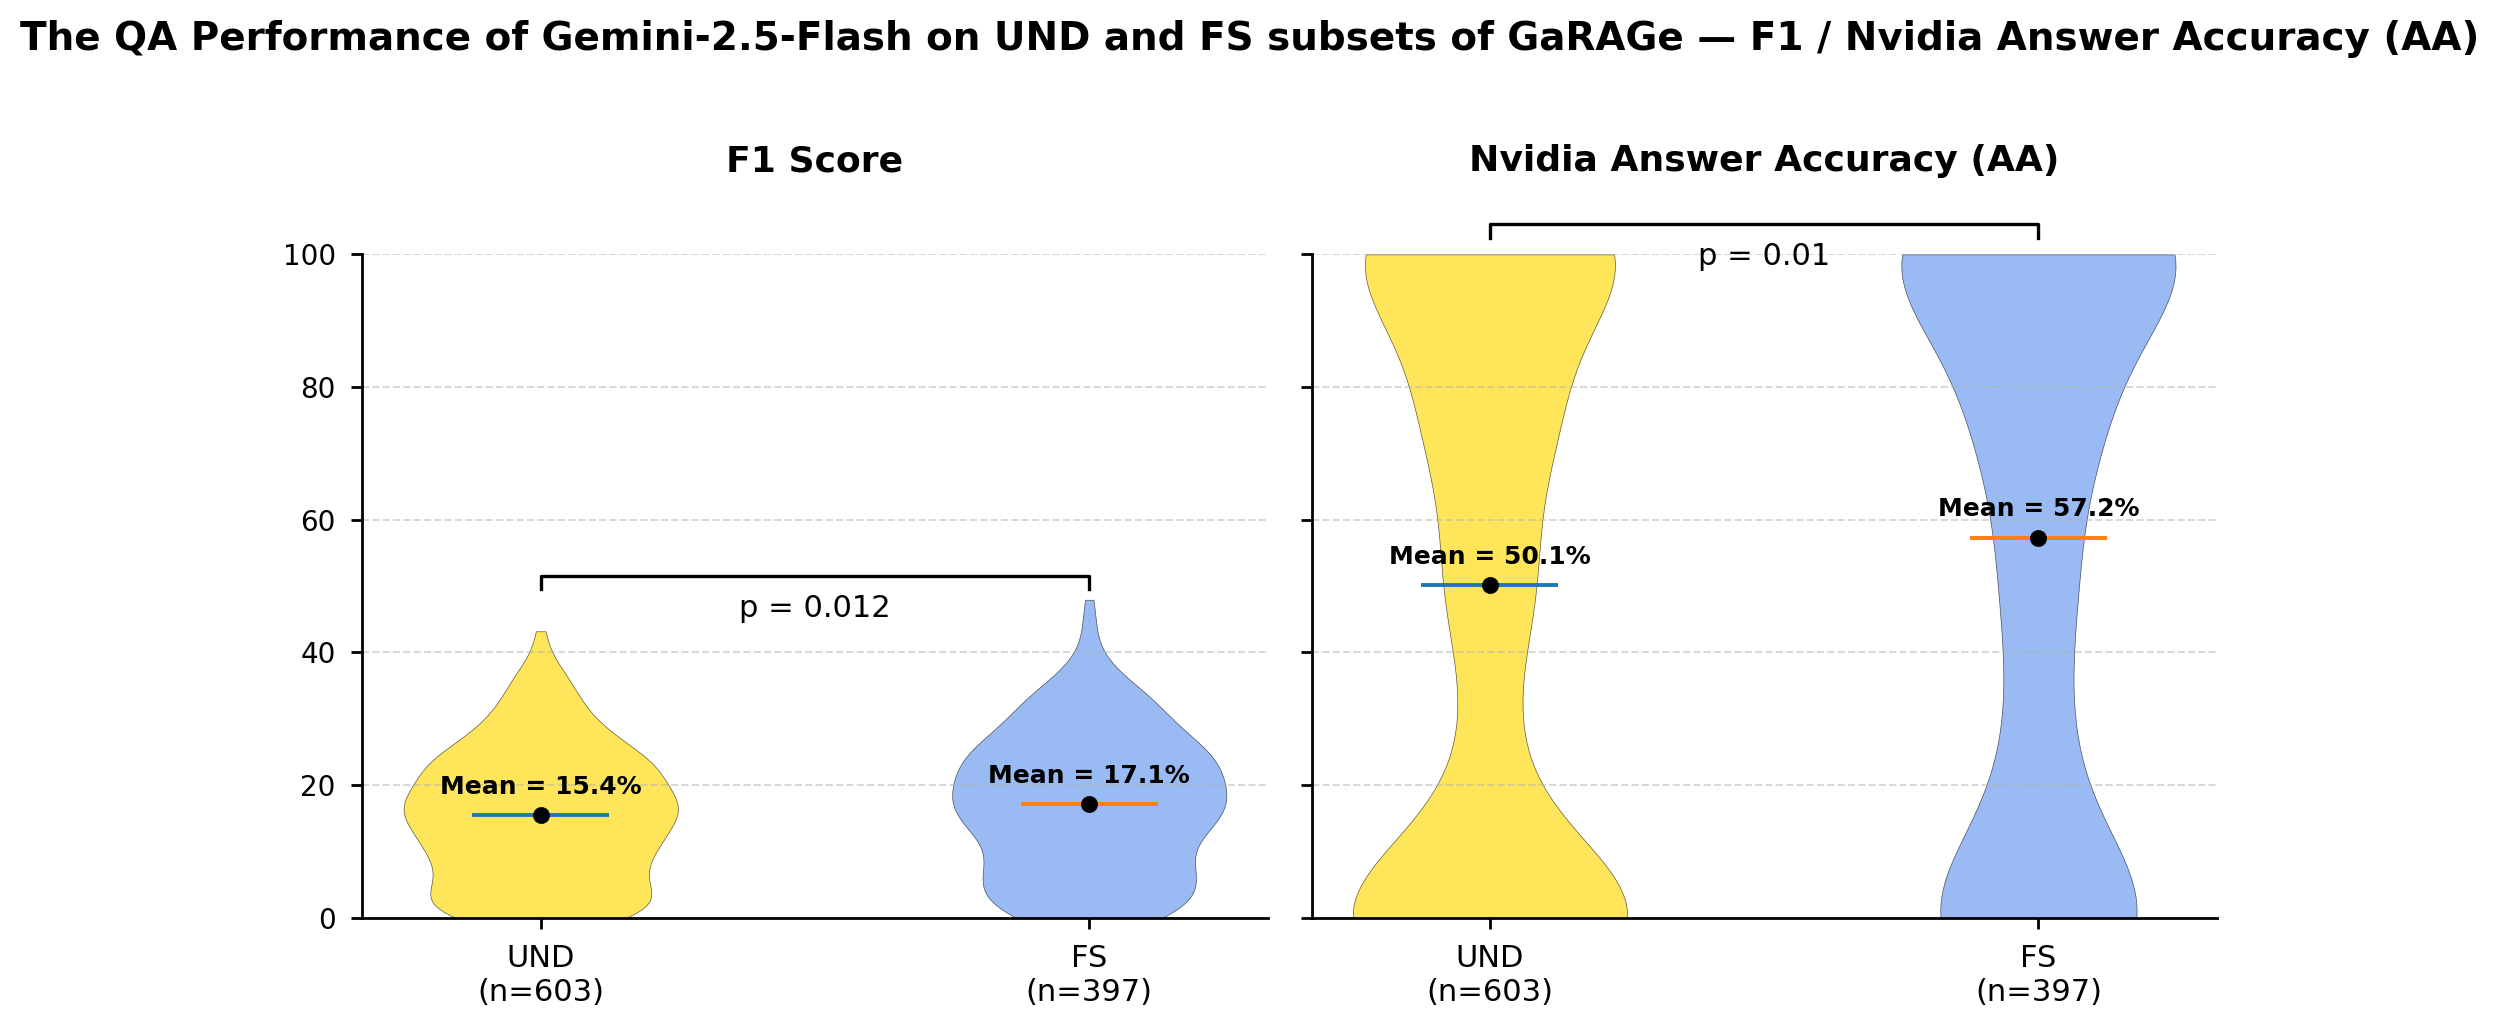

In [62]:
# Results from Gemini-2.5-Flash

und_path = "./output_csv/GaRAGe_UND_Gemini_Ragas.csv"
fs_path  = "./output_csv/GaRAGe_FS_Gemini_Ragas.csv"

COLORS = ["#FFD700", "#6495ED"]  # UND / FS
LABELS = ["UND", "FS"]

UND = pd.read_csv(und_path)
FS  = pd.read_csv(fs_path)

# 2) F1
und_f1 = to_percent_if_needed(UND["f1"].dropna().values)
fs_f1  = to_percent_if_needed(FS["f1"].dropna().values)
f1_ns  = [len(und_f1), len(fs_f1)]

# 3) RAGAS AA short
und_aa = to_percent_if_needed(UND["ragas_AA_short"].dropna().values)
fs_aa  = to_percent_if_needed(FS["ragas_AA_short"].dropna().values)
aa_ns  = [len(und_aa), len(fs_aa)]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax1, ax2 = axes

# ---- 左：F1 小提琴图 ----
for i, (vals, color) in enumerate(zip([und_f1, fs_f1], COLORS), start=1):
    parts = ax1.violinplot(vals, positions=[i],
                           showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    # 均值点与标签
    m = float(np.mean(vals))
    ax1.scatter(i, m, s=34, color="black", zorder=3)
    ax1.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_xticks([1, 2])
ax1.set_xticklabels([f"UND\n(n={f1_ns[0]})", f"FS\n(n={f1_ns[1]})"], fontsize=11)
ax1.set_title("F1 Score", fontsize=13, weight="bold", pad=30)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_ylim(0, 100)
add_pvalue_bracket(ax1, text="p = 0.012",
                   x1=1.0, x2=2.0,
                   y_top=55.0, inset=5.5, height=2.0,
                   text_x=1.5, text_dy=0.7)

# ---- 右：RAGAS AA (short) 小提琴图 ----
for i, (vals, color) in enumerate(zip([und_aa, fs_aa], COLORS), start=1):
    parts = ax2.violinplot(vals, positions=[i],
                        showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    m = float(np.mean(vals))
    ax2.scatter(i, m, s=34, color="black", zorder=3)
    ax2.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_xticks([1, 2])
ax2.set_xticklabels([f"UND\n(n={aa_ns[0]})", f"FS\n(n={aa_ns[1]})"], fontsize=11)
ax2.set_title("Nvidia Answer Accuracy (AA)", fontsize=13, weight="bold", pad=30)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 100)
add_pvalue_bracket(ax2, text="p = 0.01",
                x1=1.0, x2=2.0,
                y_top=108.0, inset=5.5, height=2.0,
                text_x=1.5, text_dy=0.7)

# ---- 总标题与布局 ----
fig.suptitle("The QA Performance of Gemini-2.5-Flash on UND and FS subsets of GaRAGe — F1 / Nvidia Answer Accuracy (AA)", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()